In [6]:
from bpd.io import load_dataset
import jax.numpy as jnp
from jax import jit
from bpd.prior import ellip_prior_e1e2
import jax.scipy as jsp

from jax import Array, grad, vmap
from jax.numpy.linalg import norm
from jax.scipy import stats

from functools import partial

import jax 
from bpd.utils import uniform_logpdf

import matplotlib.pyplot as plt
from bpd.chains import run_inference_nuts

In [7]:


from bpd.shear import (
    inv_shear_func1,
    inv_shear_func2,
    inv_shear_transformation,
)

_grad_fnc1 = vmap(vmap(grad(inv_shear_func1), in_axes=(0, None)), in_axes=(0, None))
_grad_fnc2 = vmap(vmap(grad(inv_shear_func2), in_axes=(0, None)), in_axes=(0, None))
_inv_shear_trans = vmap(inv_shear_transformation, in_axes=(0, None))

In [24]:
# use a modified version of BA2014 distribution for true prior, add m,c which are inferred jointly
# with shear

def ellip_prior_e1e2_calibrated(e1e2, *, sigma, m , 
                                c=0.0,
                               ):
    x = (e1e2 - c) / (1+m)
    return (1+m)**-1 * ellip_prior_e1e2(x, sigma=sigma)


def true_ellip_logprior(e_post, g, *, sigma_e: float, 
                        m:float,
                        # c:float
                       ):
    """Implementation of GB's true prior on interim posterior samples of ellipticities."""

    # jacobian of inverse shear transformation
    grad1 = _grad_fnc1(e_post, g)
    grad2 = _grad_fnc2(e_post, g)
    absjacdet = jnp.abs(grad1[..., 0] * grad2[..., 1] - grad1[..., 1] * grad2[..., 0])

    # true prior on unsheared ellipticity
    e_post_unsheared = _inv_shear_trans(e_post, g)
    prior_val = ellip_prior_e1e2_calibrated(e_post_unsheared, sigma=sigma_e, m=m, 
                                            # c=c
                                           )

    return jnp.log(prior_val) + jnp.log(absjacdet)

def shear_loglikelihood(
    g,
    post_params,
    *,
    logprior,
    interim_logprior
):
    """Shear Likelihood implementation of Schneider et al. 2014."""
    num = logprior(post_params, g)
    denom = interim_logprior(post_params)
    ratio = jsp.special.logsumexp(num - denom, axis=-1)
    return ratio.sum()

def logtarget(
    params,
    data,
    *,
    sigma_e_int: float,
):
    g = params['g']
    sigma_e = params['sigma_e']
    m = params['m']
    # c = params['c']

    _logprior = lambda e, g: true_ellip_logprior(e, g, sigma_e=sigma_e, m=m, 
                                                 # c=c
                                                )
    _interim_logprior = lambda e: jnp.log(ellip_prior_e1e2(e, sigma=sigma_e_int))

    loglike = shear_loglikelihood(g, e1e2, logprior=_logprior, interim_logprior=_interim_logprior)

    g_mag = jnp.sqrt(g[0] ** 2 + g[1] ** 2)
    logprior_g = uniform_logpdf(g_mag, 0.0, 1.0) + jnp.log(1 / (2 * jnp.pi))
    # logprior_m = uniform_logpdf(m, -0.5, 0.5)
    logprior_m = stats.norm.logpdf(m, loc=0.0, scale=0.1)
    # logprior_c = uniform_logpdf(m, -0.5, 0.5)
    logprior_sigma = uniform_logpdf(sigma_e, 1e-4, 1.0)

    logprior = logprior_g + logprior_m + logprior_sigma #+ logprior_c

    return loglike + logprior

In [25]:
def shear_pipeline(rng_key, init_positions, e1e2, *, logtarget):
    return run_inference_nuts(
        rng_key,
        data=e1e2,
        init_positions=init_positions,
        logtarget=_logtarget,
        n_samples=100,
        n_warmup_steps=500,
        max_num_doublings=3,
        initial_step_size=1e-2,
    )

In [26]:
samples_file = "/pscratch/sd/i/imendoza/data/cache_chains/exp70_51/interim_samples_511_plus.npz"
ds = load_dataset(samples_file)

In [27]:
e1 = ds['samples']['e1']
e2 = ds['samples']['e2']
e1.shape

(320000, 300)

In [28]:
e1e2 = jnp.stack([e1,e2],axis=-1)
e1e2.shape

(320000, 300, 2)

In [29]:
_logtarget = partial(logtarget, sigma_e_int=0.3)

In [30]:
pipe = jit(partial(shear_pipeline,logtarget=_logtarget))

In [31]:
key = jax.random.key(42)
key

Array((), dtype=key<fry>) overlaying:
[ 0 42]

In [32]:
GPU = jax.devices("gpu")[0]
e1e2 = jax.device_put(e1e2, GPU) # this is actually necessary to avoid out of memory errors


In [33]:
init_positions = {'m': 0.0,  'g':jnp.array([0.02, 0.0]), 'sigma_e':0.2, 
                # 'c':0.0,
                 }

In [34]:
# compile
_ = pipe(key, init_positions, e1e2[:2])

In [35]:
samples = pipe(key, init_positions, e1e2)

In [36]:
samples.keys(), samples['g'].shape

(dict_keys(['g', 'm', 'sigma_e']), (100, 2))

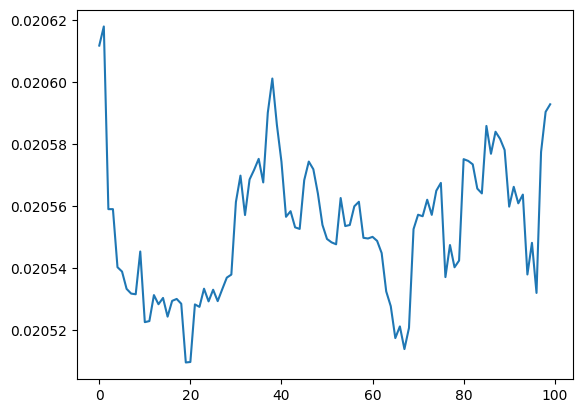

In [37]:
plt.plot(samples['g'][:, 0])

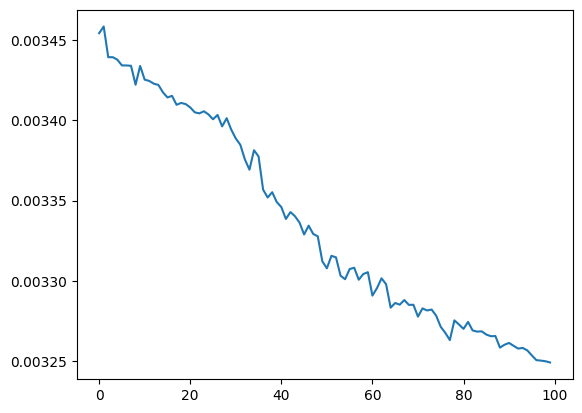

In [39]:
plt.plot(samples['sigma_e'])

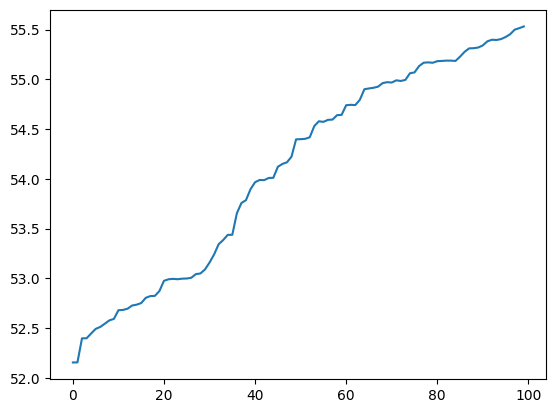

In [40]:
plt.plot(samples['m'])